# **Introduction**

This study aims to analyze the relationship between students' behavioral indicators and their academic performance, measured by total internal marks. The dataset contains various academic and behavioral attributes, including attendance percentages, assignment completion, laboratory performance, viva marks, and other learning-related indicators. Data preprocessing techniques such as handling missing values, removing duplicate records, and eliminating irrelevant features were applied to improve data quality. Exploratory Data Analysis (EDA) was performed using correlation analysis and boxplots to understand feature relationships and identify outliers. Finally, a Linear Regression model was developed to predict students' internal marks based on the selected features, and its performance was evaluated using standard regression metrics.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Read the file**

In [43]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/behavioral_indicators_internal_marks.csv')

In [44]:
df.shape

(96, 14)

In [45]:
df.sample(10)

,CRN,Theory_Attendance_Pct,Assignment_Unit_I,Assignment_Unit_II,Assignment_Unit_III,Assignment_PU_6_Set,Lab_Attendance_Pct,Lab_Report_1a,Lab_Report_1b,ML_on_Git,Viva_Marks,Final_Theory_Marks_30,Final_Practical_Marks_20,Total_Internal_Marks_50
73,023-374,93.750000,1.0,1.0,1.00,4,85.714286,1.0,1.0,4,1.0,22.960,19.0,41.960
85,023-386,75.000000,1.0,0.0,1.00,4,57.142857,1.0,1.0,4,1.5,17.080,18.0,35.080
66,023-367,93.750000,1.0,0.0,0.00,0,100.000000,1.0,1.0,4,1.5,15.000,19.5,34.500
81,023-382,81.250000,1.0,1.0,0.00,4,100.000000,1.0,1.0,4,1.0,19.540,19.0,38.540
45,023-346,100.000000,1.0,1.0,1.00,4,100.000000,1.0,1.0,4,1.5,26.000,19.5,45.500
72,023-373,50.000000,1.0,0.0,0.00,4,85.714286,0.5,0.5,4,0.5,12.660,13.5,26.160
8,023-309,22.222222,0.0,0.0,0.00,0,20.000000,0.0,0.0,0,0.0,0.280,0.0,0.280
6,023-307,77.777778,0.5,1.0,0.75,4,80.000000,1.0,1.0,4,1.0,21.710,19.0,40.710
9,023-310,27.777778,1.0,0.0,0.00,0,40.000000,0.0,0.0,0,0.0,5.200,0.0,5.200
15,023-316,88.888889,1.0,1.0,0.75,4,100.000000,1.0,1.0,4,2.0,22.046,20.0,42.046


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CRN                       96 non-null     object 
 1   Theory_Attendance_Pct     96 non-null     float64
 2   Assignment_Unit_I         96 non-null     float64
 3   Assignment_Unit_II        96 non-null     float64
 4   Assignment_Unit_III       96 non-null     float64
 5   Assignment_PU_6_Set       96 non-null     int64  
 6   Lab_Attendance_Pct        96 non-null     float64
 7   Lab_Report_1a             96 non-null     float64
 8   Lab_Report_1b             96 non-null     float64
 9   ML_on_Git                 96 non-null     int64  
 10  Viva_Marks                96 non-null     float64
 11  Final_Theory_Marks_30     96 non-null     float64
 12  Final_Practical_Marks_20  96 non-null     float64
 13  Total_Internal_Marks_50   96 non-null     float64
dtypes: float64(1

In [47]:
df['CRN'] = df['CRN'].str.replace("-","")

In [48]:
df.columns = df.columns.str.lower()

In [49]:
df['crn'] = df['crn'].astype(int)

# **Checking for missing values and handling**

In [50]:
df.isnull().sum()

,0
crn,0
theory_attendance_pct,0
assignment_unit_i,0
assignment_unit_ii,0
assignment_unit_iii,0
assignment_pu_6_set,0
lab_attendance_pct,0
lab_report_1a,0
lab_report_1b,0
ml_on_git,0


In [51]:
df[df.duplicated()]

,crn,theory_attendance_pct,assignment_unit_i,assignment_unit_ii,assignment_unit_iii,assignment_pu_6_set,lab_attendance_pct,lab_report_1a,lab_report_1b,ml_on_git,viva_marks,final_theory_marks_30,final_practical_marks_20,total_internal_marks_50


## **Checking for students with final score 0**

In [52]:
df[df['total_internal_marks_50'] == 0 ]

,crn,theory_attendance_pct,assignment_unit_i,assignment_unit_ii,assignment_unit_iii,assignment_pu_6_set,lab_attendance_pct,lab_report_1a,lab_report_1b,ml_on_git,viva_marks,final_theory_marks_30,final_practical_marks_20,total_internal_marks_50
10,23311,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
16,23317,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
33,23334,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
48,23349,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
50,23351,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
55,23356,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
63,23364,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
83,23384,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
90,23391,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
94,23395,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0


# **Removing students scoring zero**

In [53]:
df = df[~(df['total_internal_marks_50'] == 0)]
df.shape

(85, 14)

In [54]:
df.sample(10)

,crn,theory_attendance_pct,assignment_unit_i,assignment_unit_ii,assignment_unit_iii,assignment_pu_6_set,lab_attendance_pct,lab_report_1a,lab_report_1b,ml_on_git,viva_marks,final_theory_marks_30,final_practical_marks_20,total_internal_marks_50
85,23386,75.000000,1.0,0.0,1.0,4,57.142857,1.0,1.0,4,1.5,17.080,18.0,35.080
29,23330,83.333333,1.0,0.5,1.0,4,75.000000,1.0,1.0,4,1.0,22.020,13.5,35.520
20,23321,50.000000,1.0,0.0,0.0,4,80.000000,0.5,0.5,4,1.0,17.620,17.0,34.620
8,23309,22.222222,0.0,0.0,0.0,0,20.000000,0.0,0.0,0,0.0,0.280,0.0,0.280
61,23362,62.500000,1.0,1.0,0.5,4,100.000000,1.0,1.0,0,0.5,14.212,8.5,22.712
4,23305,50.000000,1.0,0.0,0.0,4,80.000000,1.0,1.0,4,1.0,13.556,18.0,31.556
70,23371,62.500000,0.0,0.0,0.0,0,100.000000,0.0,1.0,4,0.5,8.740,17.5,26.240
0,23301,38.888889,1.0,0.0,0.0,4,40.000000,0.0,0.5,0,1.0,15.760,5.5,21.260
75,23376,12.500000,1.0,0.0,0.0,4,42.857143,1.0,1.0,4,1.0,12.080,13.0,25.080
56,23357,87.500000,1.0,1.0,0.0,4,66.666667,1.0,0.5,4,1.0,18.060,14.5,32.560


# **Creating a dataframe and excluding some directly related features**

In [55]:
dfc = df.drop(columns=['crn','final_theory_marks_30','final_practical_marks_20'])

# **Visualization of Correlations Among Features**

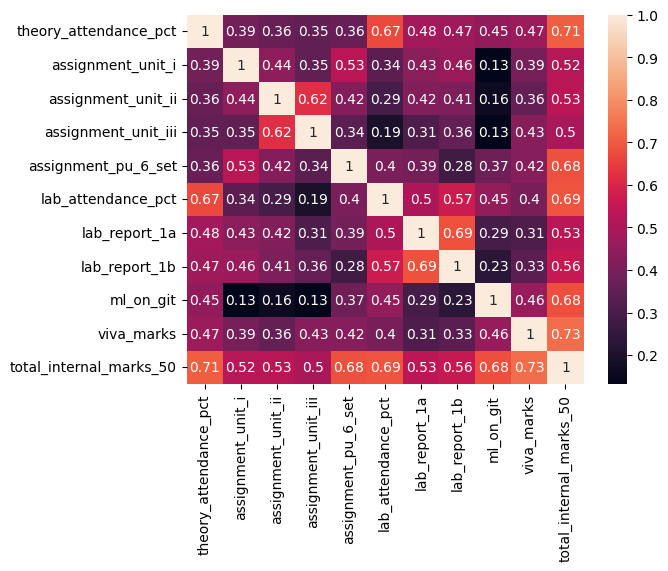

In [56]:
corr_mat2 = dfc.corr(numeric_only=True)
sns.heatmap(corr_mat2,annot=True)
plt.show()

# **Defining the targetes columns**

In [57]:
target_col_org = corr_mat2['total_internal_marks_50']
target_col_org.sort_values(ascending=False).head(7)

,total_internal_marks_50
total_internal_marks_50,1.000000
viva_marks,0.733450
theory_attendance_pct,0.706995
lab_attendance_pct,0.689479
assignment_pu_6_set,0.681988
ml_on_git,0.679285
lab_report_1b,0.556816


# **Creating new dataset for manual calculation**

In [58]:
dfc_subset = dfc[['viva_marks','theory_attendance_pct','lab_attendance_pct','total_internal_marks_50']].sample(7)
dfc_subset

,viva_marks,theory_attendance_pct,lab_attendance_pct,total_internal_marks_50
32,1.0,66.666667,37.500000,21.560
56,1.0,87.500000,66.666667,32.560
13,1.0,72.222222,100.000000,38.796
52,1.0,68.750000,50.000000,24.020
40,1.5,72.222222,75.000000,30.972
89,0.5,43.750000,71.428571,21.920
69,1.5,68.750000,83.333333,33.580


In [59]:
dfc_subset.columns

Index(['viva_marks', 'theory_attendance_pct', 'lab_attendance_pct',
       'total_internal_marks_50'],
      dtype='object')

# **Retreving my data form the dataset**

In [60]:
row = df[df['crn'] == 23307][[
    'viva_marks',
    'theory_attendance_pct',
    'lab_attendance_pct',
    'total_internal_marks_50'
]]
dfc_subset = pd.concat([dfc_subset, row])


In [61]:
dfc_subset

,viva_marks,theory_attendance_pct,lab_attendance_pct,total_internal_marks_50
32,1.0,66.666667,37.500000,21.560
56,1.0,87.500000,66.666667,32.560
13,1.0,72.222222,100.000000,38.796
52,1.0,68.750000,50.000000,24.020
40,1.5,72.222222,75.000000,30.972
89,0.5,43.750000,71.428571,21.920
69,1.5,68.750000,83.333333,33.580
6,1.0,77.777778,80.000000,40.710


# **Exploratory data analysis**

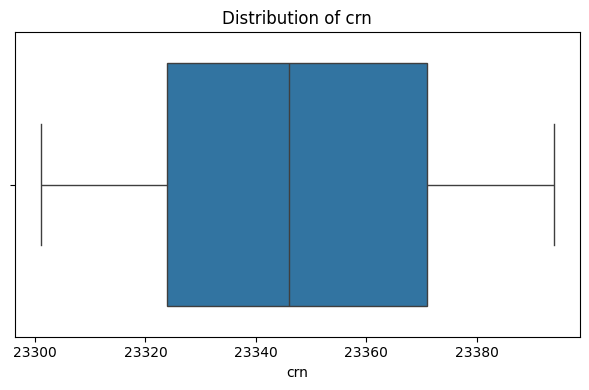

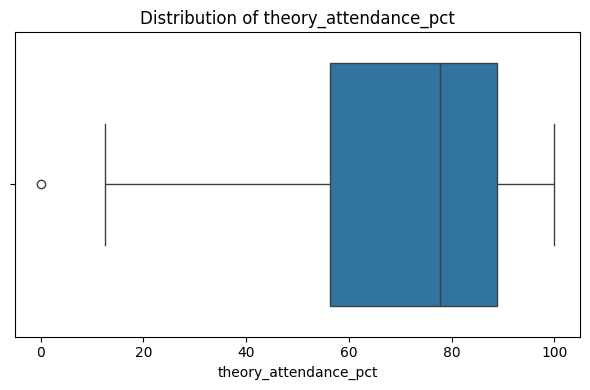

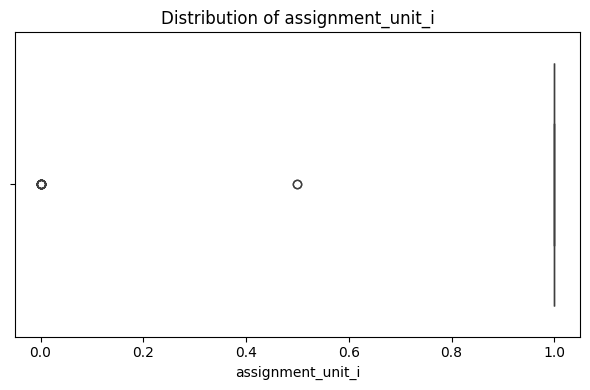

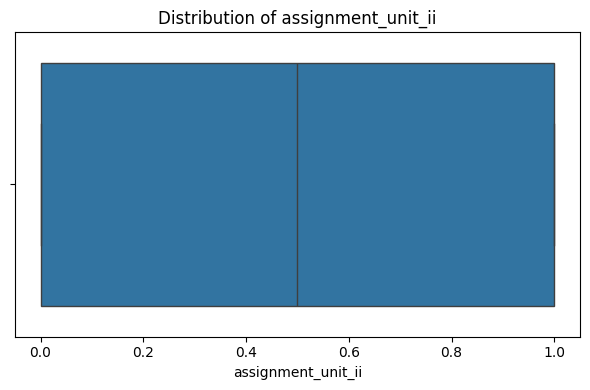

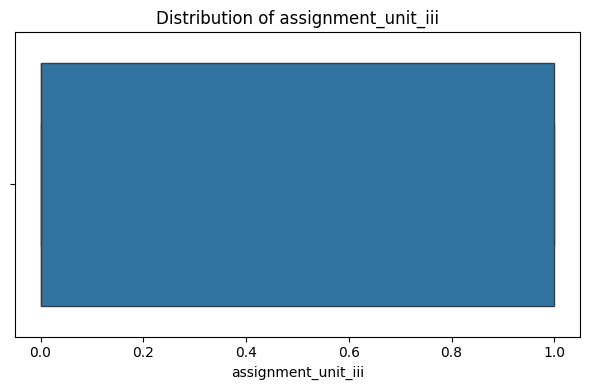

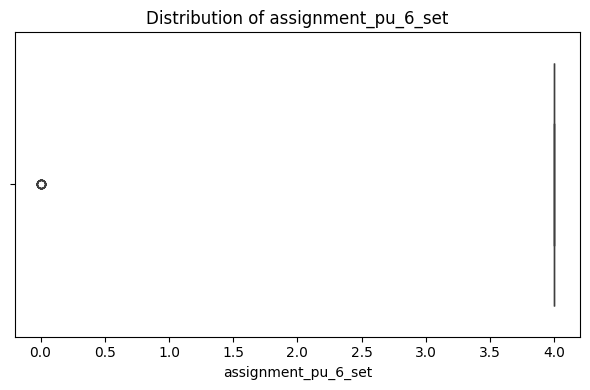

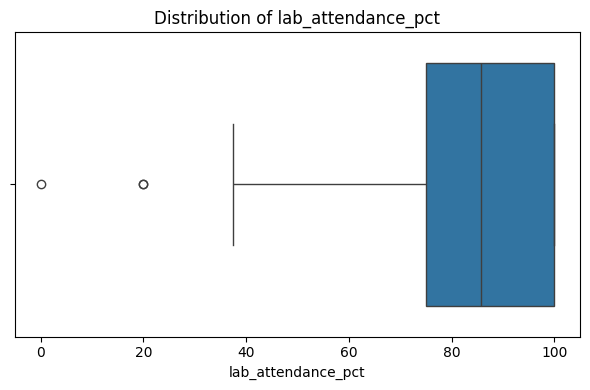

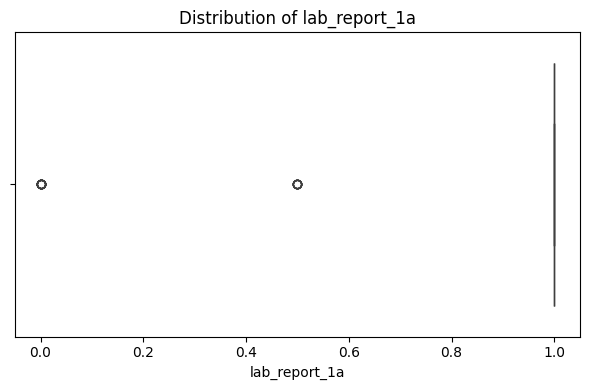

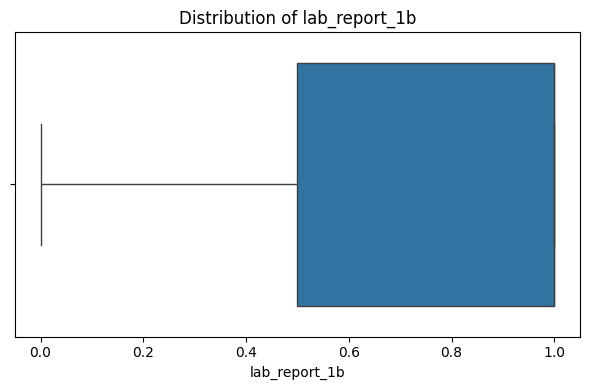

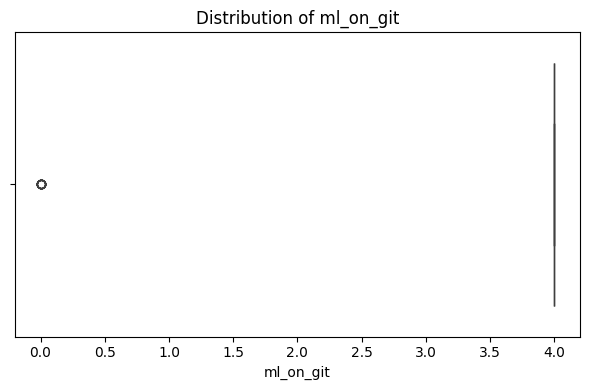

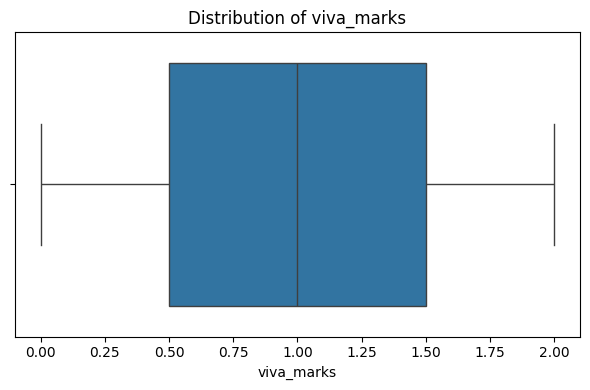

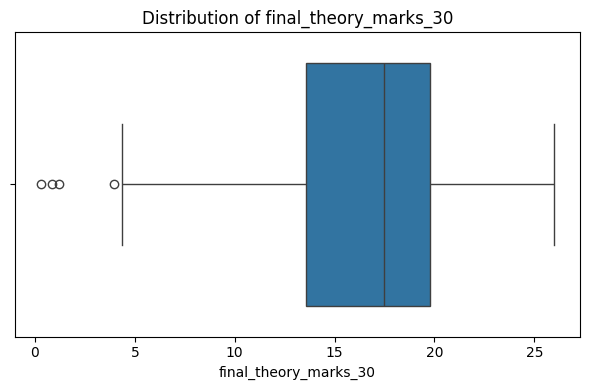

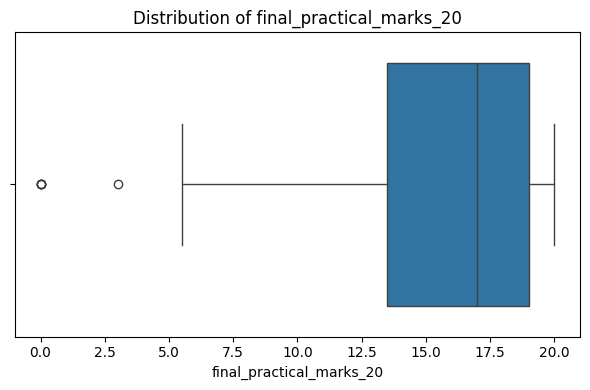

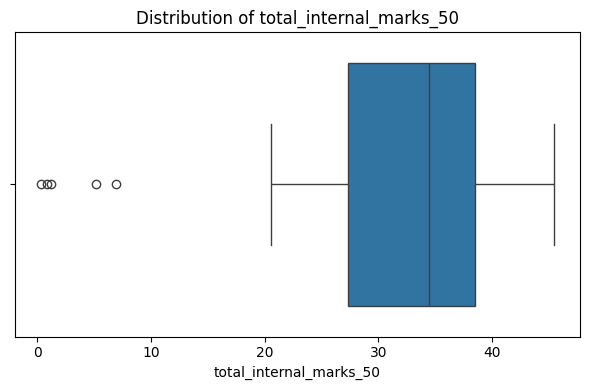

In [62]:
numeric_cols = df.select_dtypes(include=['number']).columns
for col_name in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col_name)
    plt.title(f'Distribution of {col_name}')
    plt.tight_layout()
    plt.show()

# **Looking for outliers**

In [63]:
df[df['total_internal_marks_50'] < 15]

,crn,theory_attendance_pct,assignment_unit_i,assignment_unit_ii,assignment_unit_iii,assignment_pu_6_set,lab_attendance_pct,lab_report_1a,lab_report_1b,ml_on_git,viva_marks,final_theory_marks_30,final_practical_marks_20,total_internal_marks_50
5,23306,0.000000,0.0,0.0,0.0,0,20.000000,0.0,0.0,0,0.0,1.20,0.0,1.20
8,23309,22.222222,0.0,0.0,0.0,0,20.000000,0.0,0.0,0,0.0,0.28,0.0,0.28
9,23310,27.777778,1.0,0.0,0.0,0,40.000000,0.0,0.0,0,0.0,5.20,0.0,5.20
34,23335,44.444444,0.0,0.0,0.0,0,37.500000,0.0,0.0,0,0.0,0.84,0.0,0.84
67,23368,56.250000,1.0,0.0,0.0,0,66.666667,1.0,1.0,0,0.0,3.94,3.0,6.94


# **Records with extremely low academic activity and mostly zero-valued behavioral indicators were identified using boxplots and subsequently removed.**

In [64]:
df = df[~(df['total_internal_marks_50'] < 10)]
df.shape

(80, 14)

In [65]:
df = df.drop(columns=['crn','final_theory_marks_30','final_practical_marks_20'])

# **Features Splitting**

In [66]:
X = df.drop(columns=['total_internal_marks_50'])
y = df['total_internal_marks_50']
print(X.shape)
print(y.shape)

(80, 10)
(80,)


# **The dataset was split into training and testing sets, followed by model training and performance evaluation.**

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.33, random_state=42)
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2.32499969337065
MSE: 7.8160960242499975
RMSE: 2.795728174241909
R2 Score: 0.6952226840056286


In [68]:
beta = model.coef_
intercept = model.intercept_
print(beta)
print(intercept)

[ 0.07653998  0.9674821   0.90199172  2.74453204  1.52683375  0.05529147
 -1.94882155  3.19104638  1.66427667  4.50059288]
2.8164731852162355


# **Conclusion**

The analysis demonstrated that several academic and behavioral indicators are associated with students' internal marks. Through data cleaning, outlier removal, and correlation analysis, the dataset was refined to improve model reliability. A Linear Regression model was trained using the selected features to predict total internal marks. The results indicate that attendance, viva performance, and other academic engagement factors contribute significantly to student performance. The study highlights the usefulness of machine learning techniques in educational data analysis and provides insights that can help educators identify factors influencing academic success and support students more effectively.
